In [84]:
from scipy.io import arff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [67]:
# Load the .arff file
path = 'C:\\Users\\mason\\OneDrive\\Desktop\\MATH_3310\\MP_2\\MATH3310_FA_2025_P02_G01_RALLS\\MATH3310_FA_2025_P02_G01_RALLS\\data\\raw\\phpn1jVwe.arff' # Update this to the path of your .arff file
data, meta = arff.loadarff(path)

In [68]:
# Convert to DataFrame
df = pd.DataFrame(data)

In [69]:
df['class'] = df['class'].str.decode('utf-8')

In [40]:
# Save to CSV file
csv_file_name = 'Mammography.csv'
df.to_csv(csv_file_name, index=False)
print(f"Data saved to {csv_file_name}")

Data saved to Mammography.csv


In [70]:
df.head()

,attr1,attr2,attr3,attr4,attr5,attr6,class
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,-1
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,-1
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,-1
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,-1
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,-1


In [71]:
df['class'] = df['class'].map({'-1': 0, '1': 1})
df.head()

,attr1,attr2,attr3,attr4,attr5,attr6,class
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,0
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,0
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,0
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,0
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,0


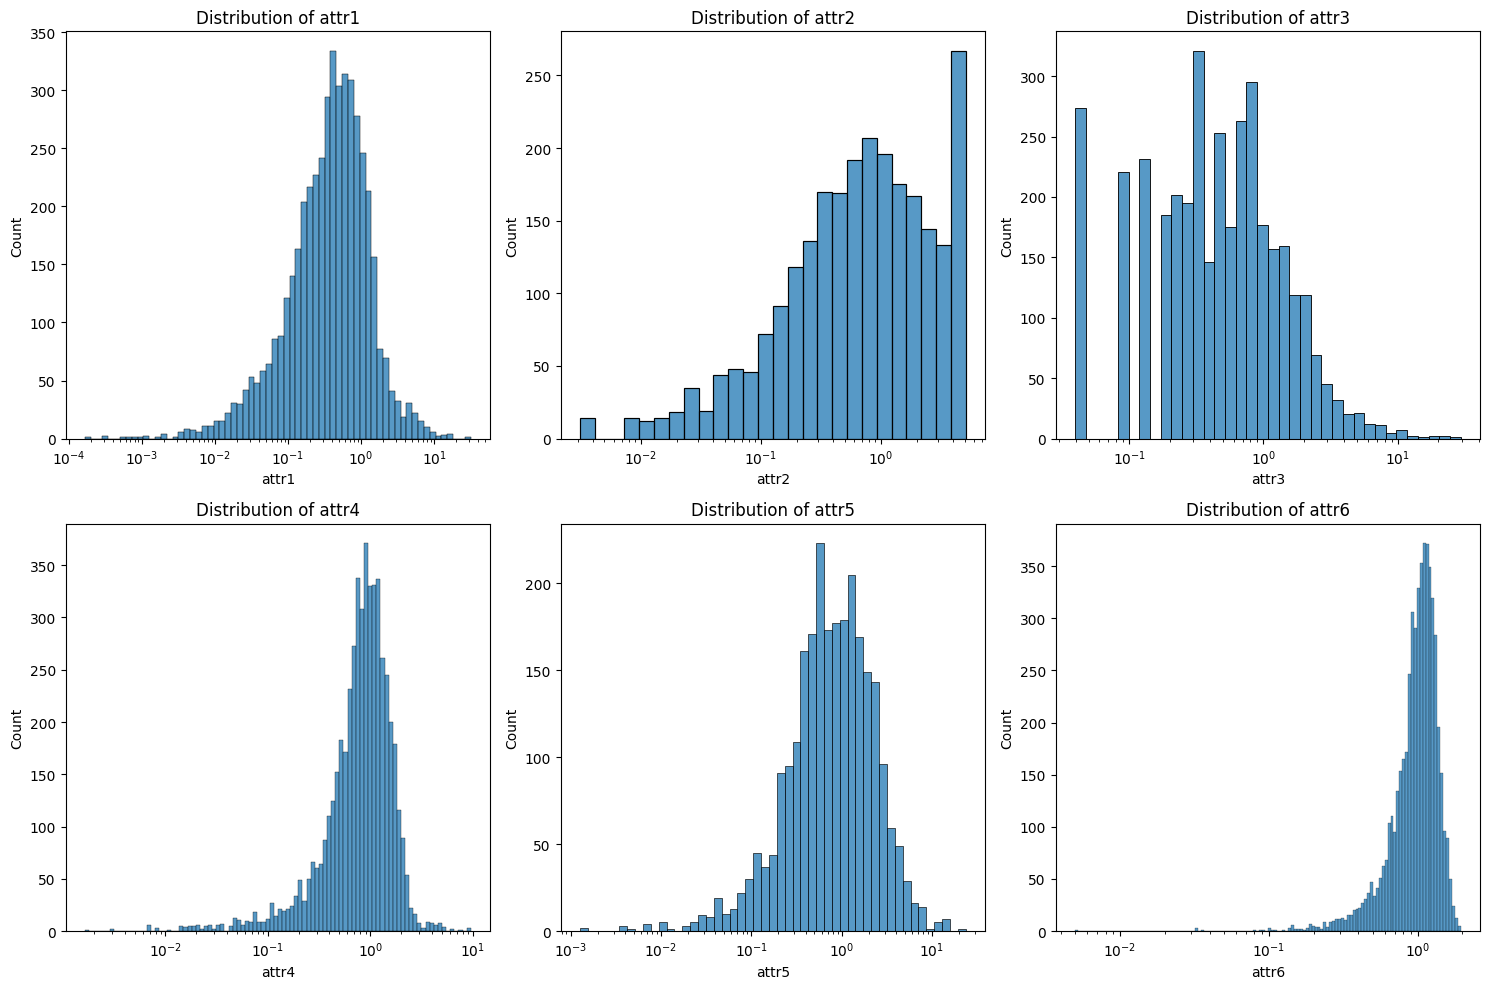

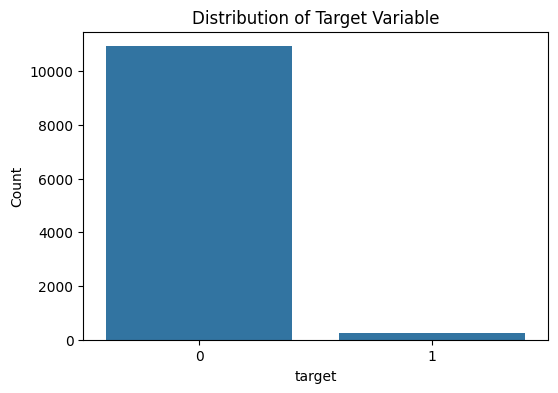

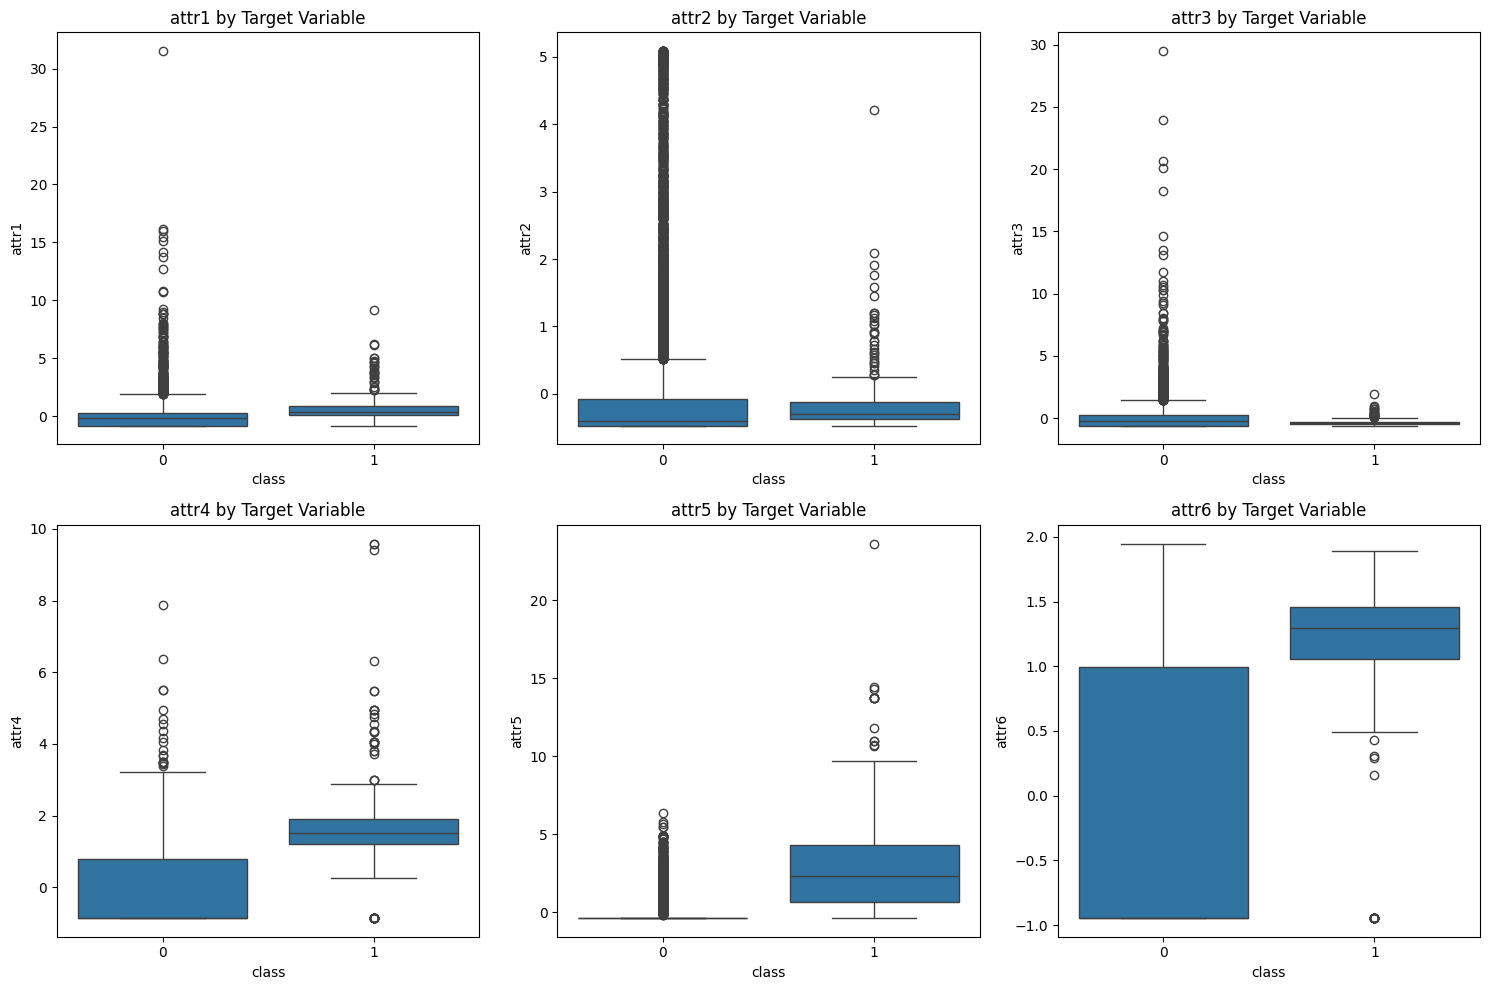

In [72]:
# Visualize the univariate distribution of each continuous feature, and the distribution of the target variable

# Set up the figure
plt.figure(figsize=(15, 10))
# List of continuous features
continuous_features = ['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6']
# Plot histograms for continuous features (log scale for x-axis)
for i, feature in enumerate(continuous_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[feature], kde=False, log_scale=(True, False))
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()
# Plot the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df)
plt.title('Distribution of Target Variable')
plt.xlabel('target')
plt.ylabel('Count')
plt.show()
# Visualize the bivariate relationships between the continuous features and the target variable
# Set up the figure
plt.figure(figsize=(15, 10))
# Plot boxplots for continuous features against the target variable
for i, feature in enumerate(continuous_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='class', y=feature, data=df)
    plt.title(f'{feature} by Target Variable')
plt.tight_layout()
plt.show()

In [73]:
#add random state to ensure reproducibility
np.random.seed(42)

# Split the data into training and testing sets
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')

Training set size: 8946
Testing set size: 2237


In [74]:
# check the data type of x_train
print(X_train.dtypes)

attr1    float64
attr2    float64
attr3    float64
attr4    float64
attr5    float64
attr6    float64
dtype: object


In [75]:
# separate numeric and categorical columns
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_features = X_train.select_dtypes(include=["object"]).columns
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [76]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [77]:
# add a random seed to ensure reproducibility

np.random.seed(42)

# define a stratified CV fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# create a pipeline that combines the preprocessor and a classifier. Use SMOTE to handle class imbalance.
pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [78]:
# evaluate the model using cross-validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1')
print(f'Cross-validation scores: {cv_scores}')
print(f'Mean cross-validation score: {cv_scores.mean()}')

Cross-validation scores: [0.5625     0.70833333 0.59047619 0.62857143 0.60606061]
Mean cross-validation score: 0.6191883116883117


In [80]:
# define the parameter grid
param_grid = [
    {
    'classifier': [DecisionTreeClassifier(random_state=0, class_weight='balanced')],
    'classifier__max_depth': [2, 3, 4],
    'classifier__min_samples_leaf': [1, 5, 10]
},
{
    'classifier': [RandomForestClassifier(random_state=0, class_weight='balanced', n_jobs=-1)],
    'classifier__n_estimators': [300, 500, 1000],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_leaf': [1, 5]
},
   {
    'classifier': [LogisticRegression(
        random_state=0,
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear'
    )],
    'classifier__C': [0.01, 0.1, 1, 10]
}

]

In [81]:
# Apply grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=skf, scoring='f1', n_jobs=-1, error_score='raise')
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier': [DecisionTreeC...andom_state=0)], 'classifier__max_depth': [2, 3, ...], 'classifier__min_samples_leaf': [1, 5, ...]}, {'classifier': [RandomForestC...andom_state=0)], 'classifier__max_depth': [None, 5, ...], 'classifier__min_samples_leaf': [1, 5], 'classifier__n_estimators': [300, 500, ...]}, ...]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [83]:
np.random.seed(42)
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Best Parameters:", best_params)
print("Best F1 Score:", best_score)

Best Parameters: {'classifier': RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=0), 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 300}
Best F1 Score: 0.634432148990907


In [87]:
y_pred = grid_search.best_estimator_.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2153   34]
 [  10   40]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2187
           1       0.54      0.80      0.65        50

    accuracy                           0.98      2237
   macro avg       0.77      0.89      0.82      2237
weighted avg       0.99      0.98      0.98      2237



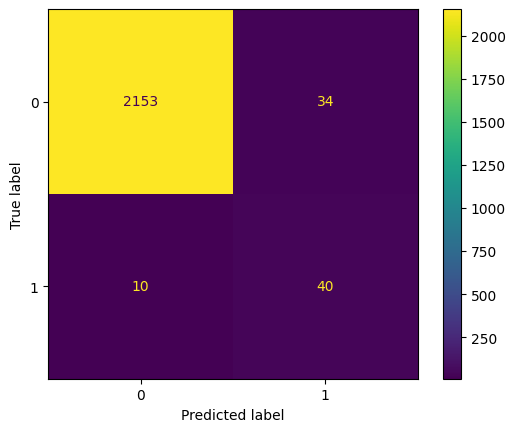

In [88]:
# plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()